# EJERCICIO : ARBOL DE DECISIÓN PARA ECOMMERCE CHURN
## DATASET [kaggle](https://www.kaggle.com/datasets/upam22/ecommerce-customer-churn-data)

# PASO 1 - INSTALAMOS E IMPORTAMOS LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set(style='whitegrid',context='notebook')

# PASO 2 CARGAMOS EL DATASET

In [3]:
df = pd.read_csv('/content/ecom_churn_cleaned.csv')
df

,churn,tenure,preferred_login_device,city_tier,warehouse_to_home,preferred_payment_mode,gender,hour_spend_on_app,number_of_device_registered,prefered_order_cat,satisfaction_score,marital_status,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,day_since_last_order,cashback_amount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,5.0,160
1,1,10.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,0.0,121
2,1,10.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,3.0,120
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,3.0,134
4,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,3.0,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,4.0,151
5626,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,5.0,225
5627,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,4.0,186
5628,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,9.0,179


# PASO 3: CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

In [4]:
categorical_columns = df.select_dtypes(object).columns
categorical_columns

Index(['preferred_login_device', 'preferred_payment_mode', 'gender',
       'prefered_order_cat', 'marital_status'],
      dtype='object')

In [5]:
for cc in categorical_columns:
  print("*"*50)
  print(df[cc].value_counts())

**************************************************
preferred_login_device
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
**************************************************
preferred_payment_mode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64
**************************************************
gender
Male      3384
Female    2246
Name: count, dtype: int64
**************************************************
prefered_order_cat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64
**************************************************
marital_status
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64


In [6]:
ordinal_cols = ['gender','marital_status']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
print(ordinal_cols,onehot_cols)

['gender', 'marital_status'] ['preferred_login_device', 'prefered_order_cat', 'preferred_payment_mode']


In [7]:
import sklearn.compose
import sklearn.preprocessing

In [8]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinalencoder', OrdinalEncoder(),
                                 ['gender', 'marital_status']),
                                ('onehotencoder', OneHotEncoder(),
                                 ['preferred_login_device',
                                  'prefered_order_cat',
                                  'preferred_payment_mode'])])

In [9]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df),
        columns = transformer.get_feature_names_out(),
        index=df.index
    )
)
data_transformed_df

,ordinalencoder__gender,ordinalencoder__marital_status,onehotencoder__preferred_login_device_Computer,onehotencoder__preferred_login_device_Mobile Phone,onehotencoder__preferred_login_device_Phone,onehotencoder__prefered_order_cat_Fashion,onehotencoder__prefered_order_cat_Grocery,onehotencoder__prefered_order_cat_Laptop & Accessory,onehotencoder__prefered_order_cat_Mobile,onehotencoder__prefered_order_cat_Mobile Phone,...,remainder__warehouse_to_home,remainder__hour_spend_on_app,remainder__number_of_device_registered,remainder__satisfaction_score,remainder__number_of_address,remainder__complain,remainder__order_amount_hike_fromlast_year,remainder__coupon_used,remainder__day_since_last_order,remainder__cashback_amount
0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,6.0,3.0,3.0,2.0,9.0,1.0,11.0,1.0,5.0,160.0
1,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,8.0,3.0,4.0,3.0,7.0,1.0,15.0,0.0,0.0,121.0
2,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,30.0,2.0,4.0,3.0,6.0,1.0,14.0,0.0,3.0,120.0
3,1.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,15.0,2.0,4.0,5.0,8.0,0.0,23.0,0.0,3.0,134.0
4,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,12.0,3.0,3.0,5.0,3.0,0.0,11.0,1.0,3.0,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,30.0,3.0,2.0,1.0,6.0,0.0,18.0,1.0,4.0,151.0
5626,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,13.0,3.0,5.0,5.0,6.0,0.0,16.0,1.0,5.0,225.0
5627,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,11.0,3.0,2.0,4.0,3.0,1.0,21.0,1.0,4.0,186.0
5628,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,9.0,4.0,5.0,4.0,4.0,0.0,15.0,2.0,9.0,179.0


In [10]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,gender,marital_status,preferred_login_device_Computer,preferred_login_device_Mobile Phone,preferred_login_device_Phone,prefered_order_cat_Fashion,prefered_order_cat_Grocery,prefered_order_cat_Laptop & Accessory,prefered_order_cat_Mobile,prefered_order_cat_Mobile Phone,...,warehouse_to_home,hour_spend_on_app,number_of_device_registered,satisfaction_score,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,day_since_last_order,cashback_amount
0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,6.0,3.0,3.0,2.0,9.0,1.0,11.0,1.0,5.0,160.0
1,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,8.0,3.0,4.0,3.0,7.0,1.0,15.0,0.0,0.0,121.0
2,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,30.0,2.0,4.0,3.0,6.0,1.0,14.0,0.0,3.0,120.0
3,1.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,15.0,2.0,4.0,5.0,8.0,0.0,23.0,0.0,3.0,134.0
4,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,12.0,3.0,3.0,5.0,3.0,0.0,11.0,1.0,3.0,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,30.0,3.0,2.0,1.0,6.0,0.0,18.0,1.0,4.0,151.0
5626,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,13.0,3.0,5.0,5.0,6.0,0.0,16.0,1.0,5.0,225.0
5627,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,11.0,3.0,2.0,4.0,3.0,1.0,21.0,1.0,4.0,186.0
5628,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,9.0,4.0,5.0,4.0,4.0,0.0,15.0,2.0,9.0,179.0


In [11]:
data_transformed_df.dtypes

,0
gender,float64
marital_status,float64
preferred_login_device_Computer,float64
preferred_login_device_Mobile Phone,float64
preferred_login_device_Phone,float64
prefered_order_cat_Fashion,float64
prefered_order_cat_Grocery,float64
prefered_order_cat_Laptop & Accessory,float64
prefered_order_cat_Mobile,float64
prefered_order_cat_Mobile Phone,float64


In [12]:
data_transformed_df['churn'].value_counts()

,count
churn,
0.0,4682
1.0,948


In [13]:
corr_matrix = data_transformed_df.corr()
corr_churn = corr_matrix['churn']
corr_churn.sort_values(ascending=False)

,churn
churn,1.000000
complain,0.250188
prefered_order_cat_Mobile Phone,0.154387
marital_status,0.140316
prefered_order_cat_Mobile,0.113364
number_of_device_registered,0.107939
satisfaction_score,0.105481
city_tier,0.084703
preferred_payment_mode_COD,0.083933
preferred_login_device_Phone,0.078916


<Axes: >

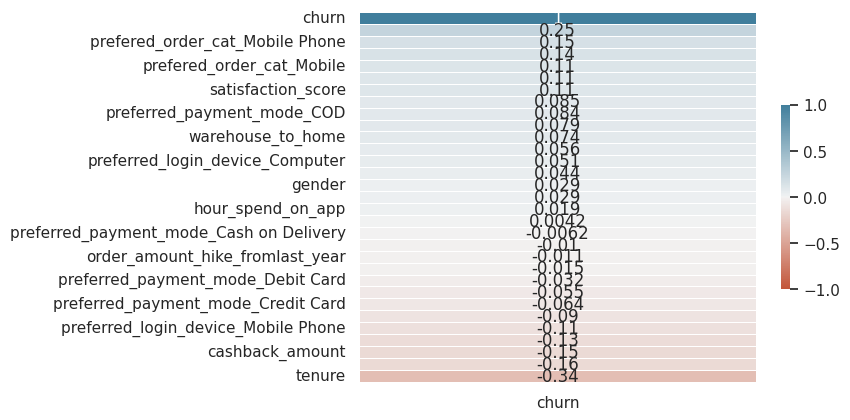

In [14]:
sns.heatmap(
    data=corr_churn.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [15]:
cols = corr_churn.index.tolist()
cols.remove('churn')
cols

['gender',
 'marital_status',
 'preferred_login_device_Computer',
 'preferred_login_device_Mobile Phone',
 'preferred_login_device_Phone',
 'prefered_order_cat_Fashion',
 'prefered_order_cat_Grocery',
 'prefered_order_cat_Laptop & Accessory',
 'prefered_order_cat_Mobile',
 'prefered_order_cat_Mobile Phone',
 'prefered_order_cat_Others',
 'preferred_payment_mode_CC',
 'preferred_payment_mode_COD',
 'preferred_payment_mode_Cash on Delivery',
 'preferred_payment_mode_Credit Card',
 'preferred_payment_mode_Debit Card',
 'preferred_payment_mode_E wallet',
 'preferred_payment_mode_UPI',
 'tenure',
 'city_tier',
 'warehouse_to_home',
 'hour_spend_on_app',
 'number_of_device_registered',
 'satisfaction_score',
 'number_of_address',
 'complain',
 'order_amount_hike_fromlast_year',
 'coupon_used',
 'day_since_last_order',
 'cashback_amount']

In [17]:
X = data_transformed_df[cols]
y = data_transformed_df['churn']

# ENTRENAMIENTO DE MODELO DE ARBOL DE DECISIÓN

In [18]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [21]:
from imblearn.over_sampling import SMOTE

# Aplicar SMOTE para balancear las clases en los datos de entrenamiento
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Conteo de clases en y_train antes de SMOTE:")
print(y_train.value_counts())
print("\nConteo de clases en y_train después de SMOTE:")
print(y_train_resampled.value_counts())

# Actualizar X_train y y_train con los datos resampleados
X_train = X_train_resampled
y_train = y_train_resampled

Conteo de clases en y_train antes de SMOTE:
churn
0.0    3741
1.0     763
Name: count, dtype: int64

Conteo de clases en y_train después de SMOTE:
churn
0.0    3741
1.0    3741
Name: count, dtype: int64


# ENTRENAMOS MODELOS DE ARBOLES DE DECISIÓN

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [23]:
param_grid = {
    'max_depth': [3,4,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'criterion':['gini','entropy']
}

clf = DecisionTreeClassifier(random_state=42)

In [24]:
grid_search = GridSearchCV(clf,param_grid,cv=5,scoring='accuracy',n_jobs=1)
grid_search.fit(X_train,y_train)
print(f'Mejor combinación de parámetros: {grid_search.best_params_}')

Mejor combinación de parámetros: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [25]:
from sklearn.metrics import accuracy_score
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f'Exactitud del modelo: {accuracy}')

Exactitud del modelo: 0.9200710479573713


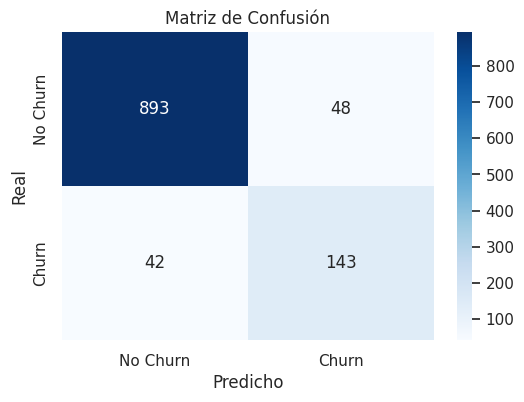

In [27]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()